# Klasifikasi Konsentrasi Boraks pada Kertas Kurkumin

Notebook ini melatih model deep learning untuk mengklasifikasikan konsentrasi boraks dari gambar ESP32-CAM. Alur utama: segmentasi area kertas kurkumin, preprocessing, split data, training MobileNetV2, evaluasi, baseline RGB, dan prediksi gambar baru.

## 1. Instalasi Library

Jalankan cell ini jika muncul error seperti `ModuleNotFoundError: No module named 'cv2'`. Setelah instalasi selesai, restart kernel Jupyter lalu jalankan notebook dari awal.

In [1]:
import sys

# cv2 berasal dari package opencv-python.
# Jalankan cell ini jika dependency belum terpasang di kernel Jupyter.
!{sys.executable} -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


## 2. Import Library dan Konfigurasi Dataset

Ubah `DATASET_DIR` jika folder dataset berada di lokasi berbeda.

In [2]:
import os
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

DATASET_SOURCE_DIR = "dataset"
RANGE_DATASET_DIR = "dataset_range"
DATASET_DIR = DATASET_SOURCE_DIR
MODEL_OUTPUT = "borax_cnn_model.h5"
IMG_SIZE = (128, 128)
RANDOM_STATE = 42
BATCH_SIZE = 16
EPOCHS = 100

CLASS_NAMES = [
    "0ppm", "100ppm", "250ppm", "500ppm", "750ppm",
    "1000ppm", "1250ppm", "1500ppm", "1750ppm", "2000ppm",
]

# Untuk dataset kecil, mode rentang biasanya lebih stabil daripada 10 kelas angka ppm persis.
# 0ppm dibuat kelas sendiri karena ini kontrol tanpa boraks.
USE_RANGE_LABELS = True
RANGE_CLASS_NAMES = ["0ppm", "100-250ppm", "500-1000ppm", "1250-2000ppm"]
ORIGINAL_TO_RANGE = {
    "0ppm": "0ppm",
    "100ppm": "100-250ppm",
    "250ppm": "100-250ppm",
    "500ppm": "500-1000ppm",
    "750ppm": "500-1000ppm",
    "1000ppm": "500-1000ppm",
    "1250ppm": "1250-2000ppm",
    "1500ppm": "1250-2000ppm",
    "1750ppm": "1250-2000ppm",
    "2000ppm": "1250-2000ppm",
}
ACTIVE_CLASS_NAMES = RANGE_CLASS_NAMES if USE_RANGE_LABELS else CLASS_NAMES

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("Dataset sumber:", Path(DATASET_SOURCE_DIR).resolve())
print("Mode label:", "rentang" if USE_RANGE_LABELS else "10 kelas asli")
print("Label aktif:", ACTIVE_CLASS_NAMES)

TensorFlow: 2.21.0
Dataset sumber: C:\Users\LENOVO\Documents\project\detection-boraks-esp32cam\detection-boraks-esp32cam\dataset
Mode label: rentang
Label aktif: ['0ppm', '100-250ppm', '500-1000ppm', '1250-2000ppm']


## 3. Bentuk Dataset Rentang

Cell ini membuat folder `dataset_range` dari dataset asli. Dataset asli tidak dihapus atau diubah. Jika `USE_RANGE_LABELS = True`, training akan memakai `dataset_range`.

In [3]:
def prepare_range_dataset(source_dir=DATASET_SOURCE_DIR, output_dir=RANGE_DATASET_DIR):
    source_dir = Path(source_dir)
    output_dir = Path(output_dir)
    if not source_dir.exists():
        raise FileNotFoundError(f"Dataset sumber tidak ditemukan: {source_dir}")

    output_dir.mkdir(parents=True, exist_ok=True)
    for range_name in RANGE_CLASS_NAMES:
        (output_dir / range_name).mkdir(parents=True, exist_ok=True)

    copied = 0
    for original_name, range_name in ORIGINAL_TO_RANGE.items():
        original_dir = source_dir / original_name
        if not original_dir.exists():
            print(f"Skip, folder tidak ada: {original_dir}")
            continue
        target_dir = output_dir / range_name
        for image_path in original_dir.iterdir():
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                target_path = target_dir / image_path.name
                if not target_path.exists():
                    shutil.copy2(image_path, target_path)
                    copied += 1
    return copied


if USE_RANGE_LABELS:
    copied = prepare_range_dataset()
    DATASET_DIR = RANGE_DATASET_DIR
    print(f"Dataset rentang siap: {Path(DATASET_DIR).resolve()}")
    print(f"File baru disalin: {copied}")
else:
    DATASET_DIR = DATASET_SOURCE_DIR
    print(f"Memakai dataset asli: {Path(DATASET_DIR).resolve()}")

Dataset rentang siap: C:\Users\LENOVO\Documents\project\detection-boraks-esp32cam\detection-boraks-esp32cam\dataset_range
File baru disalin: 0


## 4. Cek Distribusi Dataset

Dataset kecil harus dicek lebih dulu. Setelah mode rentang aktif, target kelas berubah menjadi kelas pada `ACTIVE_CLASS_NAMES`.

In [4]:
class_counts = []
for class_name in ACTIVE_CLASS_NAMES:
    class_dir = Path(DATASET_DIR) / class_name
    count = 0
    if class_dir.exists():
        count = sum(1 for path in class_dir.iterdir() if path.suffix.lower() in IMAGE_EXTENSIONS)
    class_counts.append({"kelas": class_name, "jumlah_gambar": count})

class_counts_df = pd.DataFrame(class_counts)
display(class_counts_df)
print("Total gambar:", int(class_counts_df["jumlah_gambar"].sum()))

,kelas,jumlah_gambar
0,0ppm,16
1,100-250ppm,32
2,500-1000ppm,48
3,1250-2000ppm,64


Total gambar: 160


## 5. Fungsi Segmentasi Otomatis Kertas Kurkumin

Gambar dikonversi ke HSV, lalu area kertas dicari dengan threshold warna kurkumin yang dibuat lebih lebar. Dataset ini memuat kertas kuning pada 0ppm dan area reaksi oranye/coklat pada ppm tinggi, sehingga threshold `H: 20-40` saja terlalu sempit. Notebook memakai rentang utama `H: 8-70, S: 35-255, V: 35-255`, lalu kontur terbesar dianggap sebagai area kertas. Jika kontur tidak ditemukan, notebook memakai fallback crop tengah.

In [54]:
def center_crop(image_bgr, ratio=0.6):
    height, width = image_bgr.shape[:2]
    crop_w = int(width * ratio)
    crop_h = int(height * ratio)
    x1 = max((width - crop_w) // 2, 0)
    y1 = max((height - crop_h) // 2, 0)
    return image_bgr[y1:y1 + crop_h, x1:x1 + crop_w]


def segment_curcumin_paper(image_bgr, output_size=IMG_SIZE, return_mask=False):
    """
    Segmentasi area kertas kurkumin menggunakan kombinasi:
    1. Konversi ke HSV, ambil channel Saturation (nilai tinggi untuk area berwarna)
    2. Threshold adaptif Otsu pada channel S
    3. Morfologi untuk membersihkan noise
    4. Ambil kontur terbesar (dengan asumsi kertas adalah objek terluas dalam frame)
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    s_channel = hsv[:, :, 1]  # saturation channel
    
    # Threshold Otsu (adaptive)
    _, thresh = cv2.threshold(s_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Morfologi: tutup lubang kecil, buang noise
    kernel = np.ones((5,5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    
    # Cari kontur
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        # fallback: crop tengah 70%
        h, w = image_bgr.shape[:2]
        ch, cw = int(h*0.7), int(w*0.7)
        y1 = (h - ch)//2
        x1 = (w - cw)//2
        crop = image_bgr[y1:y1+ch, x1:x1+cw]
        bbox = None
    else:
        # Ambil kontur terbesar (area)
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        if area < 500:  # jika terlalu kecil, fallback
            return segment_curcumin_paper(image_bgr, output_size, return_mask, fallback=True)
        x, y, w, h = cv2.boundingRect(largest)
        # Beri padding 5% agar tidak terpotong
        pad = int(0.05 * max(w, h))
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(image_bgr.shape[1], x + w + pad)
        y2 = min(image_bgr.shape[0], y + h + pad)
        crop = image_bgr[y1:y2, x1:x2]
        bbox = (x1, y1, x2-x1, y2-y1)
    
    if output_size:
        crop = cv2.resize(crop, output_size, interpolation=cv2.INTER_AREA)
    
    if return_mask:
        # mask dari thresh setelah morfologi
        return crop, thresh, bbox
    return crop


def to_active_label(label_name):
    if label_name in ACTIVE_CLASS_NAMES:
        return label_name
    if USE_RANGE_LABELS:
        return ORIGINAL_TO_RANGE[label_name]
    return label_name


def iter_dataset_images(dataset_dir):
    dataset_dir = Path(dataset_dir)
    expected_folders = ACTIVE_CLASS_NAMES if USE_RANGE_LABELS else CLASS_NAMES
    for class_name in expected_folders:
        class_dir = dataset_dir / class_name
        if not class_dir.exists():
            print(f"Warning: class folder not found: {class_dir}")
            continue
        active_label = to_active_label(class_name)
        class_index = ACTIVE_CLASS_NAMES.index(active_label)
        for path in sorted(class_dir.iterdir()):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                yield path, class_index, class_name

## 6. Verifikasi Visual Hasil Segmentasi

Cell ini menampilkan gambar asli, mask HSV, dan hasil crop 128x128. Bagian ini penting untuk memastikan model benar-benar fokus pada kertas, bukan background.

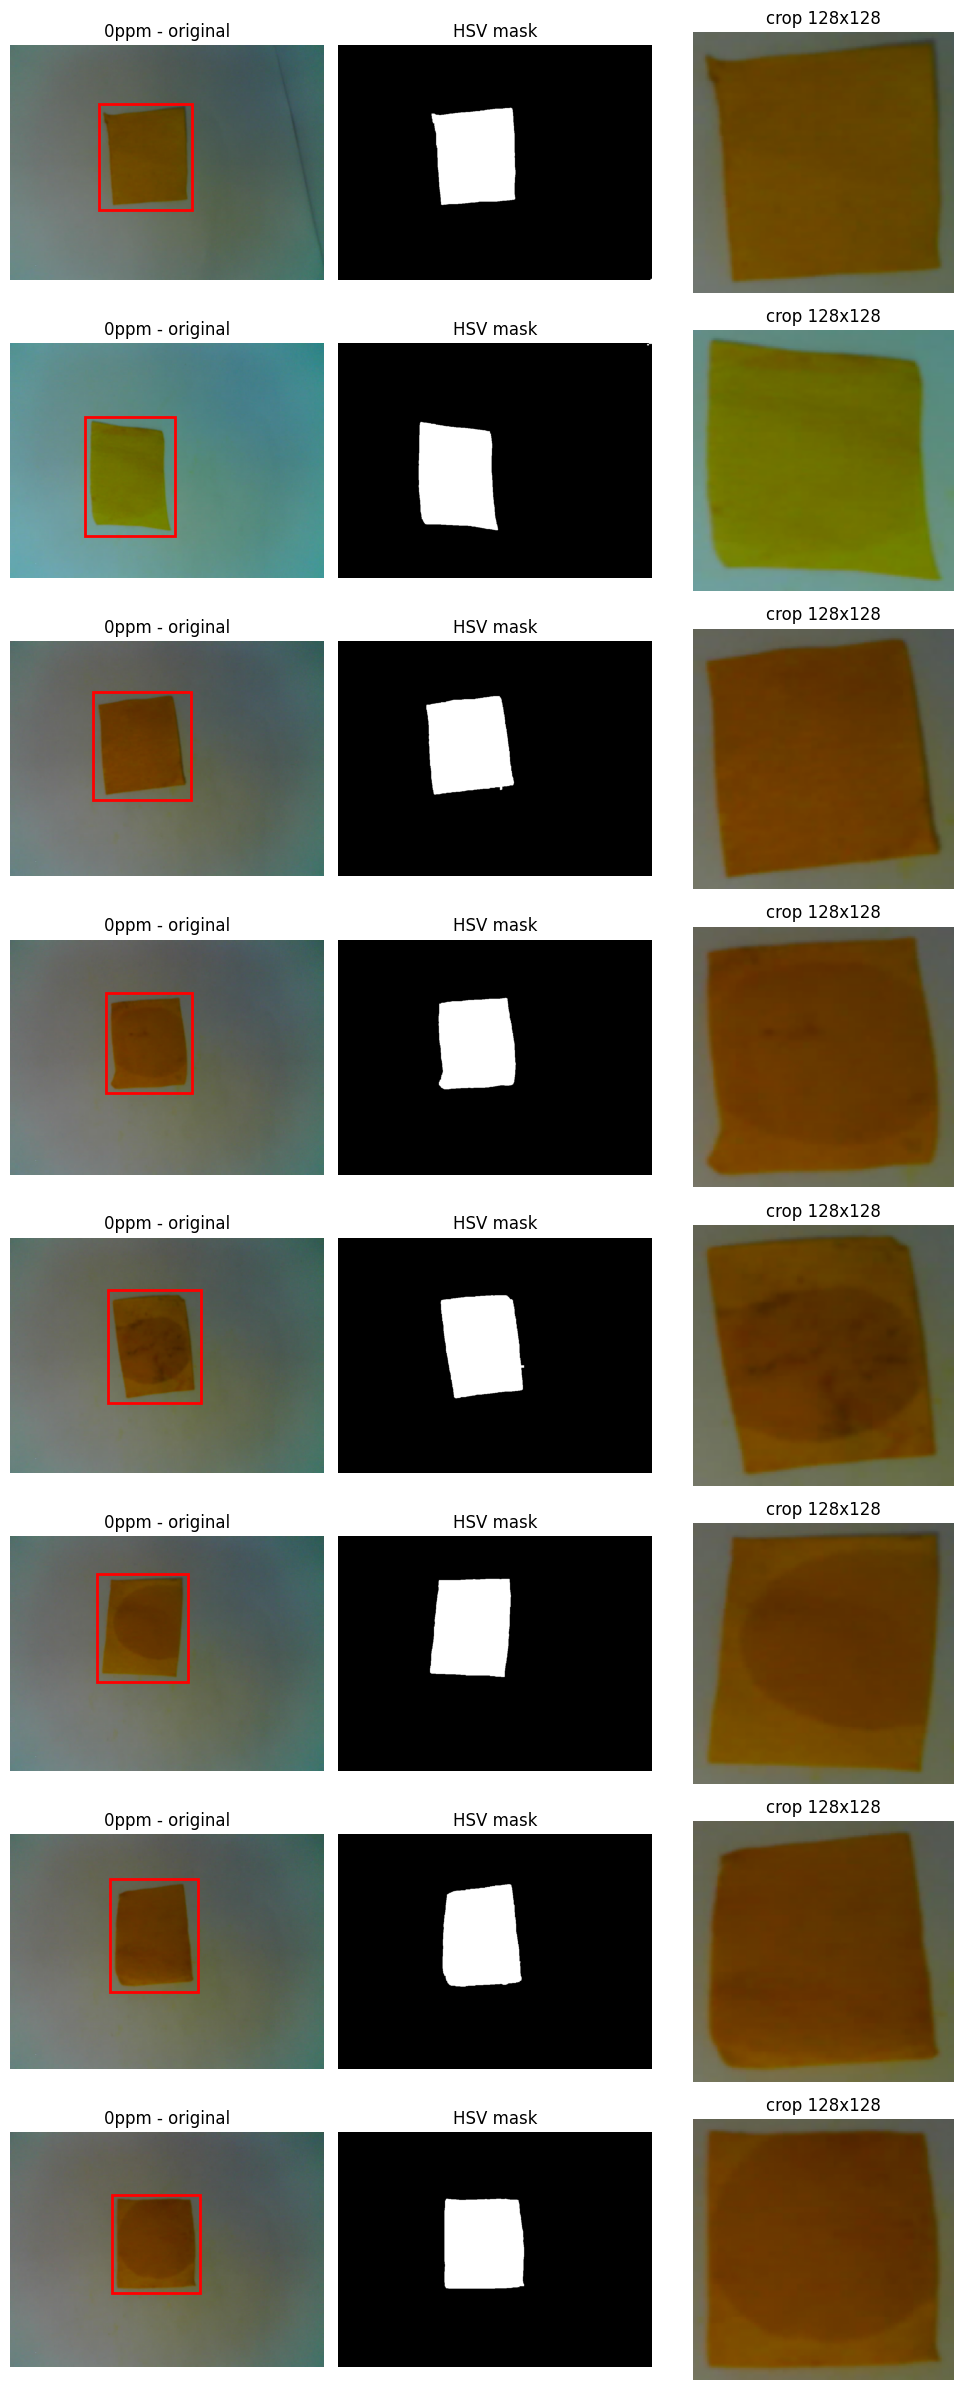

In [55]:
def show_segmentation_examples(dataset_dir, max_examples=8):
    examples = []
    for image_path, _, class_name in iter_dataset_images(dataset_dir):
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            continue
        crop_bgr, mask, bbox = segment_curcumin_paper(image_bgr, return_mask=True)
        original_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        examples.append((original_rgb, mask, crop_rgb, class_name, image_path.name, bbox))
        if len(examples) >= max_examples:
            break

    fig, axes = plt.subplots(len(examples), 3, figsize=(10, 3 * len(examples)))
    if len(examples) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, (original, mask, crop, class_name, filename, bbox) in enumerate(examples):
        axes[row, 0].imshow(original)
        axes[row, 0].set_title(f"{class_name} - original")
        if bbox:
            x, y, w, h = bbox
            axes[row, 0].add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor="red", linewidth=2))
        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title("HSV mask")
        axes[row, 2].imshow(crop)
        axes[row, 2].set_title("crop 128x128")
        for col in range(3):
            axes[row, col].axis("off")
    plt.tight_layout()
    plt.show()


show_segmentation_examples(DATASET_DIR)

## 7. Audit Kualitas Segmentasi

Sebelum training, cek berapa gambar yang berhasil ditemukan kontur kertasnya dan seberapa besar area crop terhadap gambar asli. Jika banyak fallback atau area terlalu kecil/besar, akurasi model biasanya ikut turun.

In [64]:
def audit_segmentation(dataset_dir):
    rows = []
    for image_path, _, class_name in iter_dataset_images(dataset_dir):
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            continue
        # Panggil segmentasi dengan return_mask=True, output_size=None agar tidak mengubah ukuran crop
        crop, mask, bbox = segment_curcumin_paper(image_bgr, output_size=None, return_mask=True)
        h_img, w_img = image_bgr.shape[:2]
        if bbox:
            x, y, w, h = bbox
            area_ratio = (w * h) / (w_img * h_img)
            # Hitung jumlah piksel mask dalam bounding box (pixel area kertas)
            mask_pixels = int(np.count_nonzero(mask[y:y+h, x:x+w]))
            status = "detected"
        else:
            area_ratio = np.nan
            mask_pixels = int(np.count_nonzero(mask))
            status = "fallback"
        rows.append({
            "filename": image_path.name,
            "kelas": class_name,
            "status": status,
            "area_ratio": area_ratio,
            "mask_pixels": mask_pixels,
        })
    return pd.DataFrame(rows)

seg_audit_df = audit_segmentation(DATASET_DIR)
display(seg_audit_df.groupby(["kelas", "status"]).size().unstack(fill_value=0))
display(seg_audit_df.groupby("kelas")[["area_ratio", "mask_pixels"]].mean())
print("Fallback count:", int((seg_audit_df["status"] == "fallback").sum()))

status,detected
kelas,
0ppm,16
100-250ppm,32
1250-2000ppm,64
500-1000ppm,48


,area_ratio,mask_pixels
kelas,,
0ppm,0.136767,76123.937500
100-250ppm,0.161018,81356.562500
1250-2000ppm,0.153812,78067.281250
500-1000ppm,0.165329,80046.354167


Fallback count: 0


## 8. Load Dataset dan Split Stratified 70/15/15

Setiap gambar disegmentasi, diresize ke 128x128, dinormalisasi ke rentang 0-1, lalu dibagi menjadi training, validation, dan testing dengan stratify label.

In [65]:
def load_dataset(dataset_dir):
    images, labels, paths = [], [], []
    for image_path, class_index, class_name in iter_dataset_images(dataset_dir):
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            print(f"Skip unreadable image: {image_path}")
            continue
        crop_bgr = segment_curcumin_paper(image_bgr)
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        images.append(crop_rgb.astype("float32") / 255.0)
        labels.append(class_index)
        paths.append(str(image_path))

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)
    paths = np.array(paths)
    if len(images) == 0:
        raise RuntimeError(f"No images loaded from dataset: {dataset_dir}")
    return images, labels, paths


x, y, paths = load_dataset(DATASET_DIR)
x_train, x_temp, y_train, y_temp, paths_train, paths_temp = train_test_split(
    x, y, paths, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
x_val, x_test, y_val, y_test, paths_val, paths_test = train_test_split(
    x_temp, y_temp, paths_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("Total:", len(x))
print("Train:", len(x_train), "Validation:", len(x_val), "Test:", len(x_test))
print("Image shape:", x_train.shape[1:])

split_df = pd.DataFrame({
    "kelas": ACTIVE_CLASS_NAMES,
    "train": [int(np.sum(y_train == i)) for i in range(len(ACTIVE_CLASS_NAMES))],
    "validation": [int(np.sum(y_val == i)) for i in range(len(ACTIVE_CLASS_NAMES))],
    "test": [int(np.sum(y_test == i)) for i in range(len(ACTIVE_CLASS_NAMES))],
})
display(split_df)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(ACTIVE_CLASS_NAMES)),
    y=y_train,
)
class_weight = {index: float(weight) for index, weight in enumerate(weights)}
print("Class weight:", class_weight)

Total: 160
Train: 112 Validation: 24 Test: 24
Image shape: (128, 128, 3)


,kelas,train,validation,test
0,0ppm,11,2,3
1,100-250ppm,22,5,5
2,500-1000ppm,34,7,7
3,1250-2000ppm,45,10,9


Class weight: {0: 2.5454545454545454, 1: 1.2727272727272727, 2: 0.8235294117647058, 3: 0.6222222222222222}


## 9. Data Augmentation Aman Warna

Augmentasi hanya rotasi kecil, translasi, dan flip horizontal. Tidak ada brightness, contrast, hue, atau augmentasi lain yang mengubah informasi warna.

In [66]:
def color_safe_augmentation():
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomRotation(5 / 360),
            tf.keras.layers.RandomTranslation(0.1, 0.1),
            tf.keras.layers.RandomFlip("horizontal"),
        ],
        name="color_safe_augmentation",
    )

## 10. Arsitektur Model

Model utama menggunakan MobileNetV2 dengan `weights='imagenet'`, `include_top=False`, dan semua layer base model dibekukan. Custom CNN ringan tersedia sebagai pembanding, tetapi MobileNetV2 lebih diprioritaskan untuk dataset kecil.

In [67]:
def build_mobilenetv2_model(num_classes):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE[1], IMG_SIZE[0], 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 3))
    x = color_safe_augmentation()(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs, name="borax_mobilenetv2")


def build_light_cnn_model(num_classes):
    return tf.keras.Sequential(
        [
            tf.keras.Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 3)),
            color_safe_augmentation(),
            tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(num_classes, activation="softmax"),
        ],
        name="borax_light_cnn",
    )


ARCHITECTURE = "mobilenetv2"  # pilih "mobilenetv2" atau "light_cnn"
model = build_mobilenetv2_model(len(ACTIVE_CLASS_NAMES)) if ARCHITECTURE == "mobilenetv2" else build_light_cnn_model(len(ACTIVE_CLASS_NAMES))
model.summary()

Model: "borax_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ color_safe_augmentation         │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_2 (Multiply)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 11. Compile dan Training Model

Optimizer Adam memakai learning rate 0.0001. Callback EarlyStopping dan ReduceLROnPlateau dipakai untuk mengurangi risiko overfitting.

In [68]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_borax_model.h5",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger("training_log.csv"),
    tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor="val_loss"),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, monitor="val_loss"),
]

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    class_weight=class_weight,
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3115 - loss: 1.9288
Epoch 1: val_loss improved from None to 1.51568, saving model to best_borax_model.h5



Epoch 1: finished saving model to best_borax_model.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 347ms/step - accuracy: 0.3036 - loss: 2.3705 - val_accuracy: 0.2083 - val_loss: 1.5157 - learning_rate: 1.0000e-04
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.3391 - loss: 1.7418
Epoch 2: val_loss improved from 1.51568 to 1.46536, saving model to best_borax_model.h5



Epoch 2: finished saving model to best_borax_model.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.3214 - loss: 2.1701 - val_accuracy: 0.2083 - val_loss: 1.4654 - learning_rate: 1.0000e-04
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2898 - loss: 2.0617
Epoch 3: val_loss improved from 1.46536 to 1.42235, saving model to best_borax_model.h5



Epoch 3: finished saving model to best_borax_model.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.2589 - loss: 2.3087 - val_accuracy: 0.2083 - val_loss: 1.4223 - learning_rate: 1.0000e-04
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3178 - loss: 1.6961
Epoch 4: val_loss improved from 1.42235 to 1.39153, saving model to best_borax_model.h5



Epoch 4: finished saving model to best_borax_model.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.2857 - loss: 2.0806 - val_accuracy: 0.2083 - val_loss: 1.3915 - learning_rate: 1.0000e-04
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3261 - loss: 1.9451
Epoch 5: val_loss improved from 1.39153 to 1.37282, saving model to best_borax_model.h5


...


Epoch 26: finished saving model to best_borax_model.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.3750 - loss: 1.8177 - val_accuracy: 0.5417 - val_loss: 1.1423 - learning_rate: 1.0000e-04
Epoch 27/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4101 - loss: 1.4459
Epoch 27: val_loss improved from 1.14228 to 1.13971, saving model to best_borax_model.h5



Epoch 27: finished saving model to best_borax_model.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - accuracy: 0.3750 - loss: 1.6938 - val_accuracy: 0.5417 - val_loss: 1.1397 - learning_rate: 1.0000e-04
Epoch 28/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3929 - loss: 1.5530
Epoch 28: val_loss did not improve from 1.13971
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.3482 - loss: 1.7419 - val_accuracy: 0.5833 - val_loss: 1.1408 - learning_rate: 1.0000e-04
Epoch 29/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2908 - loss: 1.5811
Epoch 29: val_loss did not improve from 1.13971
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.2946 - loss: 1.7142 - val_accuracy: 0.5833 - val_loss: 1.1398 - learning_rate: 1.0000e-04
Epoch 30/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3957 - loss: 1.4045
Epoch 30: val_loss improved from 1.13971 to 1.13437, saving model to best_borax_model.h5



Epoch 30: finished saving model to best_borax_model.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.3571 - loss: 1.5894 - val_accuracy: 0.5833 - val_loss: 1.1344 - learning_rate: 1.0000e-04
Epoch 31/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.2901 - loss: 1.5019
Epoch 31: val_loss improved from 1.13437 to 1.12592, saving model to best_borax_model.h5



Epoch 31: finished saving model to best_borax_model.h5
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.3304 - loss: 1.6656 - val_accuracy: 0.5833 - val_loss: 1.1259 - learning_rate: 1.0000e-04
Epoch 32/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4312 - loss: 1.5080
Epoch 32: val_loss improved from 1.12592 to 1.11808, saving model to best_borax_model.h5


OSError: [Errno 22] Unable to synchronously create file (unable to open file: name = 'best_borax_model.h5', errno = 22, error message = 'Invalid argument', flags = 13, o_flags = 302)

## 12. Plot Accuracy dan Loss

Grafik ini dipakai untuk melihat apakah model mulai overfitting atau underfitting.

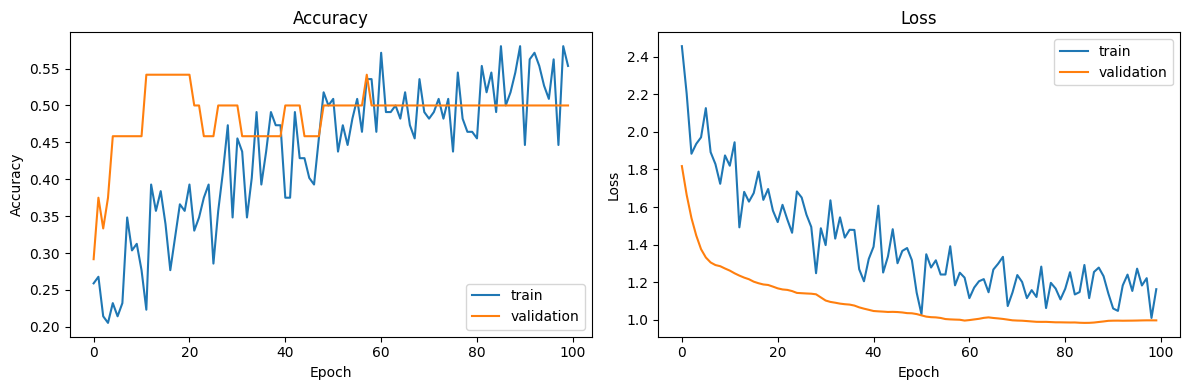

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

## 13. Evaluasi pada Data Test

Bagian ini menampilkan akurasi test, classification report, dan confusion matrix dengan label konsentrasi asli.

Test loss: 0.9926
Test accuracy: 0.5833
              precision    recall  f1-score   support

        0ppm       0.29      0.67      0.40         3
  100-250ppm       0.33      0.20      0.25         5
 500-1000ppm       0.62      0.71      0.67         7
1250-2000ppm       1.00      0.67      0.80         9

    accuracy                           0.58        24
   macro avg       0.56      0.56      0.53        24
weighted avg       0.66      0.58      0.60        24

Within-1-class accuracy: 0.9167


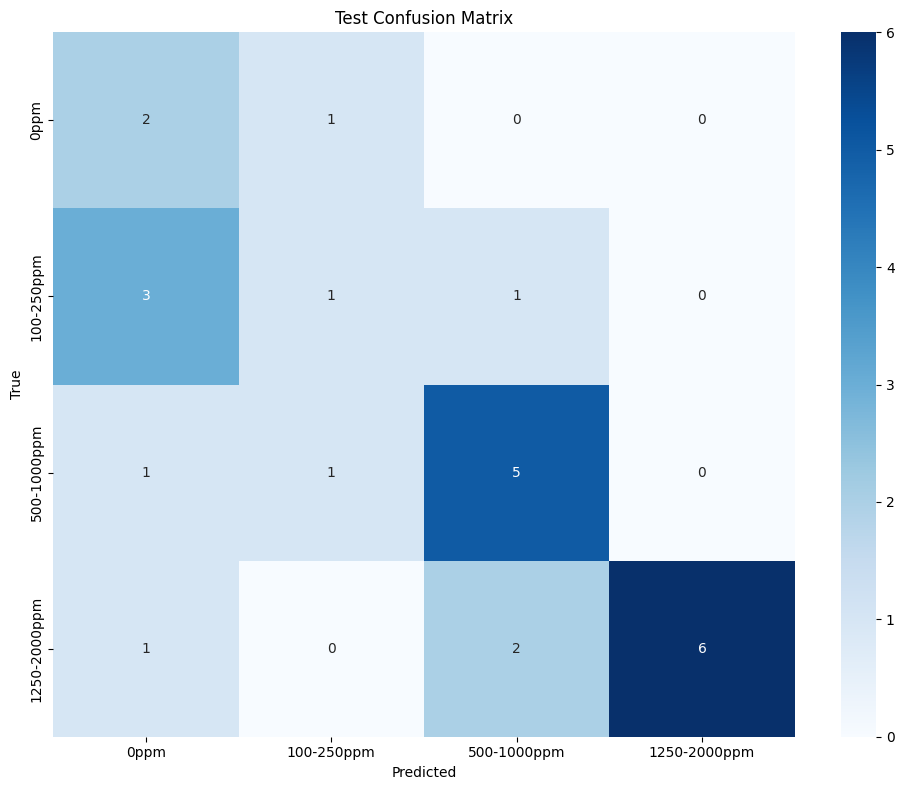

In [34]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

probabilities = model.predict(x_test, verbose=0)
y_pred = np.argmax(probabilities, axis=1)

print(classification_report(y_test, y_pred, target_names=ACTIVE_CLASS_NAMES, zero_division=0))

# Karena kelas ppm bersifat berurutan, metrik toleransi 1 level berguna untuk melihat
# apakah model salah jauh atau hanya tertukar dengan konsentrasi yang berdekatan.
within_one_step = np.mean(np.abs(y_test - y_pred) <= 1)
print(f"Within-1-class accuracy: {within_one_step:.4f}")

cm = confusion_matrix(y_test, y_pred, labels=list(range(len(ACTIVE_CLASS_NAMES))))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ACTIVE_CLASS_NAMES, yticklabels=ACTIVE_CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.show()

## 14. Contoh Prediksi 5 Gambar Test

Cell ini menampilkan gambar test, label asli, prediksi model, dan confidence.

0ppm_20260607_184104_597.jpg | true=0ppm pred=100-250ppm confidence=0.5284
0ppm_20260607_183606_822.jpg | true=0ppm pred=0ppm confidence=0.6567
250ppm_20260607_190549_382.jpg | true=100-250ppm pred=0ppm confidence=0.5499
1750ppm_20260607_141916_305.jpg | true=1250-2000ppm pred=1250-2000ppm confidence=0.8633
750ppm_20260607_191832_256.jpg | true=500-1000ppm pred=0ppm confidence=0.4159


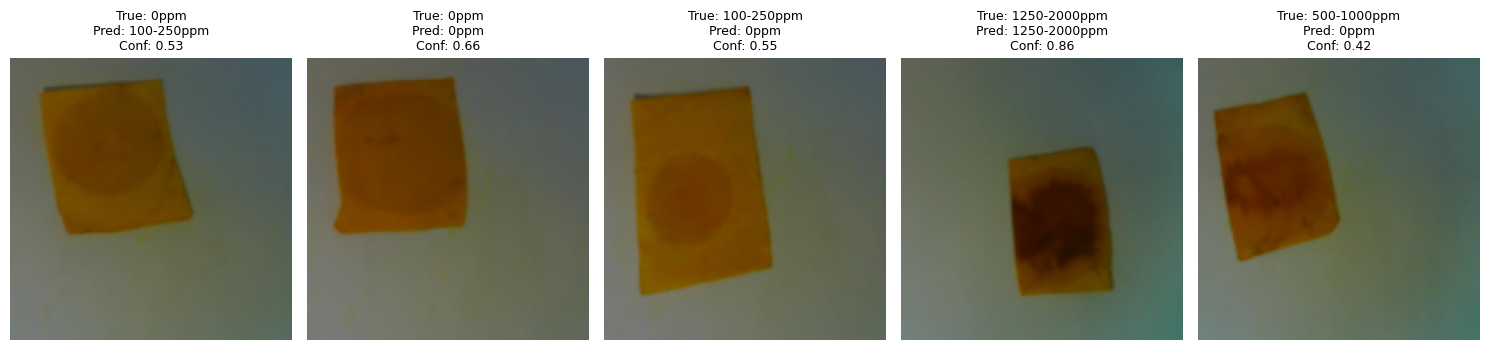

In [35]:
count = min(5, len(x_test))
fig, axes = plt.subplots(1, count, figsize=(3 * count, 3.5))
if count == 1:
    axes = [axes]

for i in range(count):
    confidence = probabilities[i, y_pred[i]]
    axes[i].imshow(x_test[i])
    axes[i].axis("off")
    axes[i].set_title(
        f"True: {ACTIVE_CLASS_NAMES[y_test[i]]}\nPred: {ACTIVE_CLASS_NAMES[y_pred[i]]}\nConf: {confidence:.2f}",
        fontsize=9,
    )
    print(
        f"{Path(paths_test[i]).name} | true={ACTIVE_CLASS_NAMES[y_test[i]]} "
        f"pred={ACTIVE_CLASS_NAMES[y_pred[i]]} confidence={confidence:.4f}"
    )

plt.tight_layout()
plt.show()

## 15. Ekstraksi RGB Rata-Rata sebagai Baseline

Fitur RGB dihitung dari area kertas yang sudah disegmentasi. Hasil disimpan ke `rgb_features.csv` dengan kolom `filename`, `kelas`, `R_mean`, `G_mean`, dan `B_mean`.

In [36]:
def extract_rgb_features(dataset_dir, output_csv="rgb_features.csv"):
    rows = []
    for image_path, _, class_name in iter_dataset_images(dataset_dir):
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            continue
        crop_bgr, mask, bbox = segment_curcumin_paper(
            image_bgr, output_size=None, return_mask=True, apply_mask=False
        )
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        if bbox:
            x, y, w, h = bbox
            crop_mask = mask[y:y + h, x:x + w]
        else:
            crop_mask = None
        if crop_mask is not None and np.count_nonzero(crop_mask) > 0:
            r_mean, g_mean, b_mean = crop_rgb[crop_mask > 0].mean(axis=0)
        else:
            r_mean, g_mean, b_mean = crop_rgb.reshape(-1, 3).mean(axis=0)
        rows.append({
            "filename": image_path.name,
            "kelas": class_name,
            "R_mean": round(float(r_mean), 4),
            "G_mean": round(float(g_mean), 4),
            "B_mean": round(float(b_mean), 4),
        })
    df = pd.DataFrame(rows, columns=["filename", "kelas", "R_mean", "G_mean", "B_mean"])
    df.to_csv(output_csv, index=False)
    return df


rgb_df = extract_rgb_features(DATASET_DIR, "rgb_features.csv")
display(rgb_df.head())
print("Rows:", len(rgb_df))

TypeError: segment_curcumin_paper() got an unexpected keyword argument 'apply_mask'

## 16. Baseline Random Forest dari Fitur RGB

Baseline ini membantu membandingkan apakah model CNN benar-benar lebih baik daripada fitur warna sederhana.

In [37]:
x_rgb = rgb_df[["R_mean", "G_mean", "B_mean"]].values
y_rgb_names = rgb_df["kelas"].apply(to_active_label)
y_rgb = y_rgb_names.map({name: index for index, name in enumerate(ACTIVE_CLASS_NAMES)}).values

x_rgb_train, x_rgb_temp, y_rgb_train, y_rgb_temp = train_test_split(
    x_rgb, y_rgb, test_size=0.30, random_state=RANDOM_STATE, stratify=y_rgb
)
x_rgb_val, x_rgb_test, y_rgb_val, y_rgb_test = train_test_split(
    x_rgb_temp, y_rgb_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_rgb_temp
)

rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_model.fit(np.vstack([x_rgb_train, x_rgb_val]), np.concatenate([y_rgb_train, y_rgb_val]))
rf_pred = rf_model.predict(x_rgb_test)
rf_acc = accuracy_score(y_rgb_test, rf_pred)
print(f"Random Forest RGB baseline test accuracy: {rf_acc:.4f}")

Random Forest RGB baseline test accuracy: 0.5000


## 17. Simpan Model Terbaik

Model disimpan dalam format `.h5` agar bisa dipakai kembali oleh script prediksi.

In [38]:
# Simpan model dari memori dan juga salin checkpoint terbaik jika tersedia.
model.save(MODEL_OUTPUT)
print(f"Model saved to {MODEL_OUTPUT}")
print("Best validation checkpoint: best_borax_model.h5")

Model saved to borax_cnn_model.h5
Best validation checkpoint: best_borax_model.h5


## 18. Fungsi Prediksi Gambar Baru

Fungsi ini memuat model, melakukan segmentasi otomatis, resize, normalisasi, lalu mengembalikan label konsentrasi dan confidence.

In [18]:
def load_saved_model(model_path=MODEL_OUTPUT):
    return tf.keras.models.load_model(model_path)


def predict_image(image_path, loaded_model=None, model_path=MODEL_OUTPUT):
    if loaded_model is None:
        loaded_model = load_saved_model(model_path)

    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found or unreadable: {image_path}")

    crop_bgr = segment_curcumin_paper(image_bgr)
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    image_array = crop_rgb.astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    probs = loaded_model.predict(image_array, verbose=0)[0]
    pred_index = int(np.argmax(probs))
    return ACTIVE_CLASS_NAMES[pred_index], float(probs[pred_index])


# Contoh penggunaan setelah model tersimpan:
# label, confidence = predict_image("dataset/1250ppm/1250ppm_20260607_193346_246.jpg")
# print(label, confidence)